# Final Model Comparison

Saved-report comparison for partition 8 models. This notebook avoids loading full parquet data or model libraries; it reads the reports generated on Longleaf.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

LOG_DIR = PROJECT_ROOT / "logs"

REPORT_PATHS = {
    "top20_lgbm": LOG_DIR / "train_top20_lgbm_report.json",
    "top20_xgb": LOG_DIR / "train_top20_xgb_report.json",
    "rolling_lgbm": LOG_DIR / "train_rolling_lgbm_report.json",
    "rolling_xgb": LOG_DIR / "train_rolling_xgb_report.json",
    "mlp_rolling": LOG_DIR / "train_mlp_rolling_report.json",
    "gru_mlp_rolling": LOG_DIR / "train_gru_mlp_rolling_report.json",
    "online_mlp_rolling": LOG_DIR / "train_online_mlp_rolling_report.json",
    "online_gru_mlp_rolling": LOG_DIR / "train_online_gru_mlp_rolling_report.json",
    "regularized_mlp_sweep": LOG_DIR / "train_regularized_mlp_sweep_report.json",
    "regularized_mlp_focused": LOG_DIR / "train_regularized_mlp_focused_report.json",
    "ensemble_all_neural": LOG_DIR / "ensemble_rolling_report.json",
    "ensemble_focused_mlp_xgb": LOG_DIR / "ensemble_focused_mlp_xgb_report.json",
}

print({name: path.exists() for name, path in REPORT_PATHS.items()})


{'top20_lgbm': True, 'top20_xgb': True, 'rolling_lgbm': True, 'rolling_xgb': True, 'mlp_rolling': True, 'gru_mlp_rolling': True, 'online_mlp_rolling': True, 'online_gru_mlp_rolling': True, 'regularized_mlp_sweep': True, 'regularized_mlp_focused': True, 'ensemble_all_neural': True, 'ensemble_focused_mlp_xgb': True}


In [2]:
def rows_from_report(name, path):
    if not path.exists():
        return []
    report = json.loads(path.read_text())
    rows = []

    if "scores" in report:
        for row in report["scores"]:
            rows.append({
                "experiment": name,
                "model": row.get("model"),
                "split": row.get("split"),
                "weighted_r2": row.get("weighted_r2"),
                "details": "ensemble/report score",
            })
        return rows

    best = report.get("best", {})
    model_label = best.get("model", best.get("name", name)) if best else name
    valid_r2 = best.get("valid_weighted_r2") if best else report.get("valid_weighted_r2", report.get("valid_online_weighted_r2"))
    test_r2 = report.get("test_weighted_r2", report.get("test_online_weighted_r2"))

    rows.append({
        "experiment": name,
        "model": model_label,
        "split": "valid",
        "weighted_r2": valid_r2,
        "details": json.dumps({k: best.get(k) for k in ["best_iteration", "best_epoch", "best_shrink", "dropout", "lr", "weight_decay", "use_embeddings"] if k in best}),
    })
    if test_r2 is not None:
        rows.append({
            "experiment": name,
            "model": model_label,
            "split": "test",
            "weighted_r2": test_r2,
            "details": "test score from report",
        })
    return rows

rows = []
for name, path in REPORT_PATHS.items():
    rows.extend(rows_from_report(name, path))

scores = pd.DataFrame(rows).dropna(subset=["weighted_r2"])
scores.sort_values("weighted_r2", ascending=False)


,experiment,model,split,weighted_r2,details
31,ensemble_focused_mlp_xgb,ensemble,valid,0.006523,ensemble/report score
30,ensemble_focused_mlp_xgb,focused_mlp_mean,valid,0.005984,ensemble/report score
25,ensemble_all_neural,ensemble,valid,0.005796,ensemble/report score
13,regularized_mlp_focused,small_no_embed_more_dropout_seed202,valid,0.005736,"{""best_epoch"": 4, ""best_shrink"": 0.75, ""dropou..."
12,regularized_mlp_sweep,small_no_embed,valid,0.005661,"{""best_epoch"": 3, ""best_shrink"": 0.75, ""dropou..."
3,rolling_xgb,shallower,valid,0.005567,"{""best_iteration"": 138}"
1,top20_xgb,shallower,valid,0.005500,"{""best_iteration"": 150}"
14,ensemble_all_neural,xgb,test,0.004996,ensemble/report score
26,ensemble_focused_mlp_xgb,xgb,test,0.004996,ensemble/report score
29,ensemble_focused_mlp_xgb,xgb,valid,0.004963,ensemble/report score


In [3]:
summary = scores.pivot_table(index=["experiment", "model"], columns="split", values="weighted_r2", aggfunc="max")
summary = summary.reindex(columns=["valid", "test"]).sort_values("valid", ascending=False)
summary


split                                                            valid  \
experiment               model                                           
ensemble_focused_mlp_xgb ensemble                             0.006523   
                         focused_mlp_mean                     0.005984   
ensemble_all_neural      ensemble                             0.005796   
regularized_mlp_focused  small_no_embed_more_dropout_seed202  0.005736   
regularized_mlp_sweep    small_no_embed                       0.005661   
rolling_xgb              shallower                            0.005567   
top20_xgb                shallower                            0.005500   
ensemble_focused_mlp_xgb xgb                                  0.004963   
ensemble_all_neural      xgb                                  0.004963   
rolling_lgbm             more_regularized                     0.004498   
top20_lgbm               more_regularized                     0.004264   
mlp_rolling              mlp_rolling                         -0.003860   
ensemble_all_neural      mlp                                 -0.003860   
                         gru_mlp                             -0.012707   
gru_mlp_rolling          gru_mlp_rolling                     -0.012707   
online_gru_mlp_rolling   online_gru_mlp_rolling              -0.105476   
ensemble_all_neural      online_gru_mlp                      -0.105476   
online_mlp_rolling       online_mlp_rolling                  -0.146223   
ensemble_all_neural      online_mlp                          -0.146223   

split                                                             test  
experiment               model                                          
ensemble_focused_mlp_xgb ensemble                             0.004425  
                         focused_mlp_mean                     0.003024  
ensemble_all_neural      ensemble                             0.004597  
regularized_mlp_focused  small_no_embed_more_dropout_seed202       NaN  
regularized_mlp_sweep    small_no_embed                            NaN  
rolling_xgb              shallower                                 NaN  
top20_xgb                shallower                                 NaN  
ensemble_focused_mlp_xgb xgb                                  0.004996  
ensemble_all_neural      xgb                                  0.004996  
rolling_lgbm             more_regularized                          NaN  
top20_lgbm               more_regularized                          NaN  
mlp_rolling              mlp_rolling                         -0.006744  
ensemble_all_neural      mlp                                 -0.006744  
                         gru_mlp                             -0.014378  
gru_mlp_rolling          gru_mlp_rolling                     -0.014378  
online_gru_mlp_rolling   online_gru_mlp_rolling              -0.082004  
ensemble_all_neural      online_gru_mlp                      -0.082004  
online_mlp_rolling       online_mlp_rolling                  -0.062946  
ensemble_all_neural      online_mlp                          -0.062946

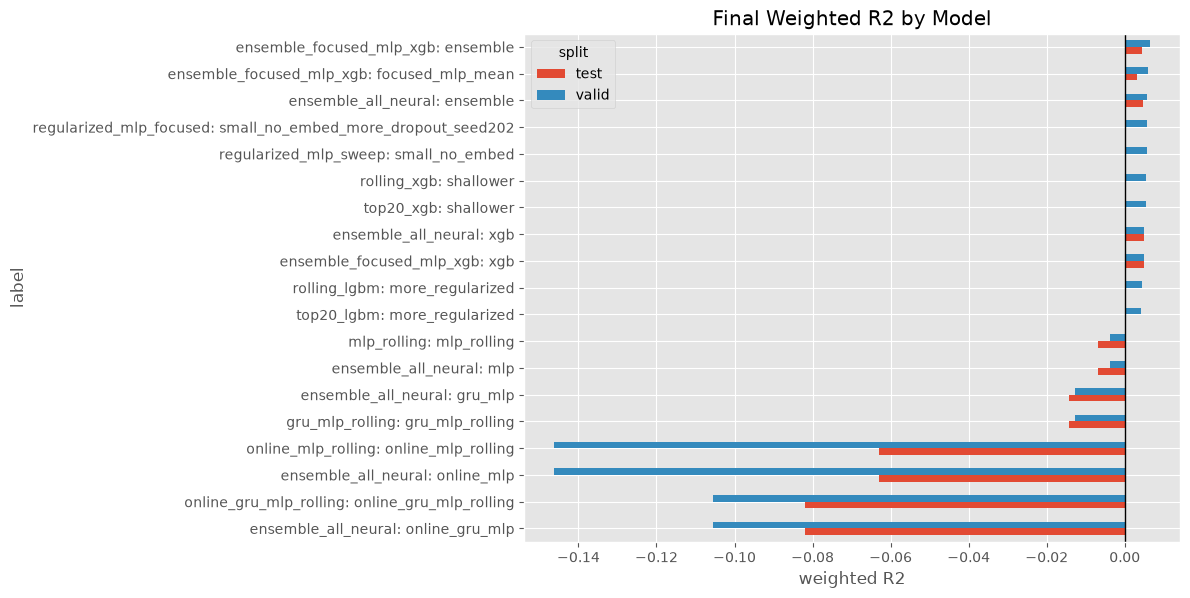

In [4]:
plot_df = scores[scores["split"].isin(["valid", "test"])].copy()
plot_df["label"] = plot_df["experiment"] + ": " + plot_df["model"].astype(str)
pivot = plot_df.pivot_table(index="label", columns="split", values="weighted_r2", aggfunc="max").fillna(0)
pivot = pivot.loc[pivot.max(axis=1).sort_values().index]

ax = pivot.plot(kind="barh", figsize=(12, max(5, len(pivot) * 0.32)))
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Final Weighted R2 by Model")
ax.set_xlabel("weighted R2")
plt.tight_layout()


In [5]:
valid_best = scores[scores["split"] == "valid"].sort_values("weighted_r2", ascending=False).head(10)
test_best = scores[scores["split"] == "test"].sort_values("weighted_r2", ascending=False).head(10)

print("Best validation models")
display(valid_best)
print("Best test models")
display(test_best)


Best validation models


,experiment,model,split,weighted_r2,details
31,ensemble_focused_mlp_xgb,ensemble,valid,0.006523,ensemble/report score
30,ensemble_focused_mlp_xgb,focused_mlp_mean,valid,0.005984,ensemble/report score
25,ensemble_all_neural,ensemble,valid,0.005796,ensemble/report score
13,regularized_mlp_focused,small_no_embed_more_dropout_seed202,valid,0.005736,"{""best_epoch"": 4, ""best_shrink"": 0.75, ""dropou..."
12,regularized_mlp_sweep,small_no_embed,valid,0.005661,"{""best_epoch"": 3, ""best_shrink"": 0.75, ""dropou..."
3,rolling_xgb,shallower,valid,0.005567,"{""best_iteration"": 138}"
1,top20_xgb,shallower,valid,0.005500,"{""best_iteration"": 150}"
29,ensemble_focused_mlp_xgb,xgb,valid,0.004963,ensemble/report score
19,ensemble_all_neural,xgb,valid,0.004963,ensemble/report score
2,rolling_lgbm,more_regularized,valid,0.004498,"{""best_iteration"": 51}"


Best test models


,experiment,model,split,weighted_r2,details
14,ensemble_all_neural,xgb,test,0.004996,ensemble/report score
26,ensemble_focused_mlp_xgb,xgb,test,0.004996,ensemble/report score
24,ensemble_all_neural,ensemble,test,0.004597,ensemble/report score
28,ensemble_focused_mlp_xgb,ensemble,test,0.004425,ensemble/report score
27,ensemble_focused_mlp_xgb,focused_mlp_mean,test,0.003024,ensemble/report score
5,mlp_rolling,mlp_rolling,test,-0.006744,test score from report
15,ensemble_all_neural,mlp,test,-0.006744,ensemble/report score
7,gru_mlp_rolling,gru_mlp_rolling,test,-0.014378,test score from report
16,ensemble_all_neural,gru_mlp,test,-0.014378,ensemble/report score
9,online_mlp_rolling,online_mlp_rolling,test,-0.062946,test score from report


## Interpretation

The focused MLP plus XGBoost ensemble achieved the best validation R2, but its test R2 was lower than rolling XGBoost. The strongest test model remained rolling XGBoost. Neural models only became competitive after strong regularization, prediction shrinkage, and focused seed/config sweeps.
